# Spherical K-Means Clustering with Haversine Distance

This notebook demonstrates how to cluster points that live on the surface of a sphere using the **great-circle (Haversine) distance** instead of the traditional Euclidean distance.

**Key concepts:**
- Points are represented as (latitude, longitude) on a unit sphere
- Distance between points is measured along the surface using the Haversine formula
- Cluster centroids are computed as spherical means (not Euclidean averages)

## 1. Setup & Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import matplotlib.colors as mcolors

np.random.seed(42)

# Sphere radius (unit sphere)
R = 1.0

print("Setup complete!")

Setup complete!


## 2. Generate Pre-Clustered Points on a Sphere

We place **seed centers** at known locations on the sphere, then scatter ~300 points around them using angular perturbation. This guarantees visible cluster structure.

In [2]:
def generate_clustered_points_on_sphere(n_points=300, n_clusters=5, spread_deg=15, seed=42):
    """
    Generate points pre-clustered around seed centers on a unit sphere.
    
    Parameters:
        n_points  : Total number of points to generate
        n_clusters: Number of seed cluster centers
        spread_deg: Angular spread (in degrees) around each center
        seed      : Random seed for reproducibility
    
    Returns:
        lats, lons          : Arrays of latitude and longitude in radians
        true_labels         : Ground truth cluster assignment for each point
        center_lats, center_lons : Seed center coordinates in radians
    """
    rng = np.random.default_rng(seed)
    spread_rad = np.deg2rad(spread_deg)
    
    # Generate seed centers spread across the sphere
    # Using a fixed set for reproducibility and good visual separation
    center_lats_deg = np.array([60, -40, 10, -60, 35])
    center_lons_deg = np.array([30, -60, 150, 80, -130])
    center_lats = np.deg2rad(center_lats_deg[:n_clusters])
    center_lons = np.deg2rad(center_lons_deg[:n_clusters])
    
    # Distribute points roughly evenly across clusters
    points_per_cluster = n_points // n_clusters
    
    all_lats = []
    all_lons = []
    all_labels = []
    
    for i in range(n_clusters):
        n = points_per_cluster if i < n_clusters - 1 else n_points - points_per_cluster * (n_clusters - 1)
        
        # Perturb around center using normal distribution on angles
        dlat = rng.normal(0, spread_rad, size=n)
        dlon = rng.normal(0, spread_rad / np.cos(center_lats[i] + 1e-8), size=n)
        
        lats = np.clip(center_lats[i] + dlat, -np.pi/2, np.pi/2)
        lons = center_lons[i] + dlon
        # Wrap longitudes to [-pi, pi]
        lons = (lons + np.pi) % (2 * np.pi) - np.pi
        
        all_lats.append(lats)
        all_lons.append(lons)
        all_labels.append(np.full(n, i))
    
    return (
        np.concatenate(all_lats),
        np.concatenate(all_lons),
        np.concatenate(all_labels),
        center_lats,
        center_lons
    )


# Generate the dataset
lats, lons, true_labels, seed_lats, seed_lons = generate_clustered_points_on_sphere(
    n_points=300, n_clusters=5, spread_deg=15
)

print(f"Generated {len(lats)} points in {len(np.unique(true_labels))} clusters")
print(f"Latitude  range: [{np.rad2deg(lats.min()):.1f}°, {np.rad2deg(lats.max()):.1f}°]")
print(f"Longitude range: [{np.rad2deg(lons.min()):.1f}°, {np.rad2deg(lons.max()):.1f}°]")

Generated 300 points in 5 clusters
Latitude  range: [-90.0°, 90.0°]
Longitude range: [-174.1°, 177.7°]


## 3. Haversine Distance

The **Haversine formula** computes the shortest distance along the surface of a sphere between two points given their latitudes and longitudes:

$$d = 2r \cdot \arcsin\left(\sqrt{\sin^2\left(\frac{\phi_2 - \phi_1}{2}\right) + \cos(\phi_1)\cos(\phi_2)\sin^2\left(\frac{\lambda_2 - \lambda_1}{2}\right)}\right)$$

In [3]:
def haversine(lat1, lon1, lat2, lon2, r=1.0):
    """
    Compute the great-circle distance between two points on a sphere
    using the Haversine formula.
    
    All angles in radians. Works element-wise on arrays.
    """
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
    # Clip to avoid numerical issues with arcsin
    a = np.clip(a, 0, 1)
    return 2 * r * np.arcsin(np.sqrt(a))


def haversine_distance_matrix(lats, lons, center_lats, center_lons, r=1.0):
    """
    Compute distance matrix between all points and all centers.
    Returns shape (n_points, n_centers).
    """
    n_points = len(lats)
    n_centers = len(center_lats)
    dist_matrix = np.zeros((n_points, n_centers))
    
    for j in range(n_centers):
        dist_matrix[:, j] = haversine(lats, lons, center_lats[j], center_lons[j], r)
    
    return dist_matrix


# Quick sanity check: antipodal points should have distance = pi * R
d = haversine(0, 0, 0, np.pi, r=R)
print(f"Distance between antipodal points: {d:.4f}  (expected: {np.pi * R:.4f})")

# Same point should have distance 0
d0 = haversine(0.5, 1.0, 0.5, 1.0, r=R)
print(f"Distance from a point to itself:   {d0:.4f}  (expected: 0.0000)")

Distance between antipodal points: 3.1416  (expected: 3.1416)
Distance from a point to itself:   0.0000  (expected: 0.0000)


## 4. Spherical K-Means Algorithm

Standard K-means won't work directly because:
1. **Distance** must follow the sphere's surface (Haversine, not Euclidean)
2. **Centroid update** must produce a point *on* the sphere (spherical mean via Cartesian averaging + re-projection)

In [4]:
def latlon_to_cartesian(lat, lon, r=1.0):
    """Convert lat/lon (radians) to 3D Cartesian coordinates."""
    x = r * np.cos(lat) * np.cos(lon)
    y = r * np.cos(lat) * np.sin(lon)
    z = r * np.sin(lat)
    return x, y, z


def cartesian_to_latlon(x, y, z):
    """Convert 3D Cartesian coordinates back to lat/lon (radians)."""
    lat = np.arcsin(np.clip(z / np.sqrt(x**2 + y**2 + z**2 + 1e-16), -1, 1))
    lon = np.arctan2(y, x)
    return lat, lon


def spherical_mean(lats, lons):
    """
    Compute the spherical mean of a set of points.
    
    Strategy: convert to Cartesian, average, project back onto sphere.
    This gives the point on the sphere that minimizes sum of squared
    great-circle distances (for points not too spread out).
    """
    x, y, z = latlon_to_cartesian(lats, lons)
    mean_x, mean_y, mean_z = np.mean(x), np.mean(y), np.mean(z)
    # Project back onto unit sphere
    norm = np.sqrt(mean_x**2 + mean_y**2 + mean_z**2)
    if norm < 1e-10:
        # Degenerate case: points cancel out (e.g. antipodal)
        return lats[0], lons[0]
    mean_x /= norm
    mean_y /= norm
    mean_z /= norm
    return cartesian_to_latlon(mean_x, mean_y, mean_z)


def spherical_kmeans(lats, lons, k=5, max_iter=100, tol=1e-6, seed=123):
    """
    K-means clustering on the sphere using Haversine distance.
    
    Parameters:
        lats, lons : Point coordinates in radians
        k          : Number of clusters
        max_iter   : Maximum number of iterations
        tol        : Convergence threshold on total distance change
        seed       : Random seed for initial centroid selection
    
    Returns:
        labels         : Cluster assignment for each point
        center_lats    : Final centroid latitudes
        center_lons    : Final centroid longitudes
        history        : List of total intra-cluster distance per iteration
    """
    rng = np.random.default_rng(seed)
    n = len(lats)
    
    # Initialize: pick k random points as initial centroids
    init_indices = rng.choice(n, size=k, replace=False)
    c_lats = lats[init_indices].copy()
    c_lons = lons[init_indices].copy()
    
    history = []
    labels = np.zeros(n, dtype=int)
    
    for iteration in range(max_iter):
        # --- Assignment step ---
        dist_matrix = haversine_distance_matrix(lats, lons, c_lats, c_lons, r=R)
        labels = np.argmin(dist_matrix, axis=1)
        
        # Record total intra-cluster distance
        total_dist = sum(dist_matrix[i, labels[i]] for i in range(n))
        history.append(total_dist)
        
        # --- Update step: spherical mean of each cluster ---
        new_c_lats = np.zeros(k)
        new_c_lons = np.zeros(k)
        for j in range(k):
            members = labels == j
            if np.sum(members) == 0:
                # Empty cluster: reinitialize to a random point
                rand_idx = rng.choice(n)
                new_c_lats[j] = lats[rand_idx]
                new_c_lons[j] = lons[rand_idx]
            else:
                new_c_lats[j], new_c_lons[j] = spherical_mean(lats[members], lons[members])
        
        # Check convergence
        centroid_shift = haversine(c_lats, c_lons, new_c_lats, new_c_lons, r=R)
        c_lats = new_c_lats
        c_lons = new_c_lons
        
        if np.max(centroid_shift) < tol:
            print(f"Converged at iteration {iteration + 1}")
            break
    else:
        print(f"Reached max iterations ({max_iter})")
    
    return labels, c_lats, c_lons, history


# Run spherical K-means
K = 5
pred_labels, final_c_lats, final_c_lons, cost_history = spherical_kmeans(
    lats, lons, k=K, max_iter=100
)

print(f"\nCluster sizes: {[np.sum(pred_labels == i) for i in range(K)]}")
print(f"Final total intra-cluster distance: {cost_history[-1]:.4f}")

Converged at iteration 4

Cluster sizes: [np.int64(54), np.int64(63), np.int64(7), np.int64(61), np.int64(115)]
Final total intra-cluster distance: 130.9583


## 5. Visualization

### 5a. 3D Sphere Plot

Points colored by predicted cluster, with centroids marked as large stars.

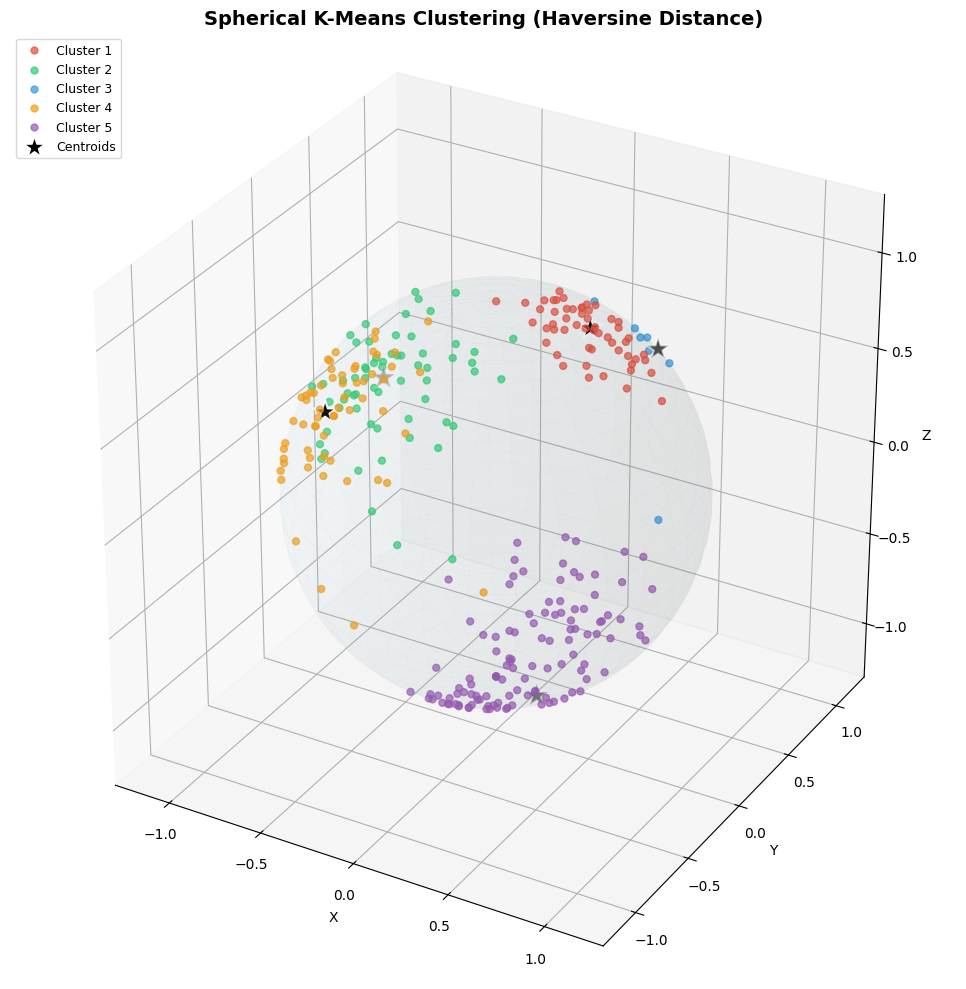

In [5]:
# Color palette for clusters
cluster_colors = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12', '#9b59b6']

# Convert all points to Cartesian for 3D plotting
px, py, pz = latlon_to_cartesian(lats, lons)
cx, cy, cz = latlon_to_cartesian(final_c_lats, final_c_lons)

# Draw a wireframe sphere
phi_grid = np.linspace(0, 2 * np.pi, 60)
theta_grid = np.linspace(-np.pi/2, np.pi/2, 30)
phi_mesh, theta_mesh = np.meshgrid(phi_grid, theta_grid)
xs = R * np.cos(theta_mesh) * np.cos(phi_mesh)
ys = R * np.cos(theta_mesh) * np.sin(phi_mesh)
zs = R * np.sin(theta_mesh)

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Translucent sphere surface
ax.plot_surface(xs, ys, zs, alpha=0.05, color='lightblue', edgecolor='gray', linewidth=0.1)

# Plot points by cluster
for i in range(K):
    mask = pred_labels == i
    ax.scatter(px[mask], py[mask], pz[mask],
               c=cluster_colors[i], s=25, alpha=0.7, label=f'Cluster {i+1}', depthshade=True)

# Plot centroids
ax.scatter(cx, cy, cz, c='black', marker='*', s=300, edgecolors='white',
           linewidths=1.5, zorder=10, label='Centroids')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Spherical K-Means Clustering (Haversine Distance)', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)

# Clean up axis limits
ax.set_xlim([-1.3, 1.3])
ax.set_ylim([-1.3, 1.3])
ax.set_zlim([-1.3, 1.3])
ax.set_box_aspect([1, 1, 1])

plt.tight_layout()
plt.show()

### 5b. 2D Latitude–Longitude Map Projection

A flat "world map" view showing the clusters, with Voronoi-like background shading to indicate cluster territories.

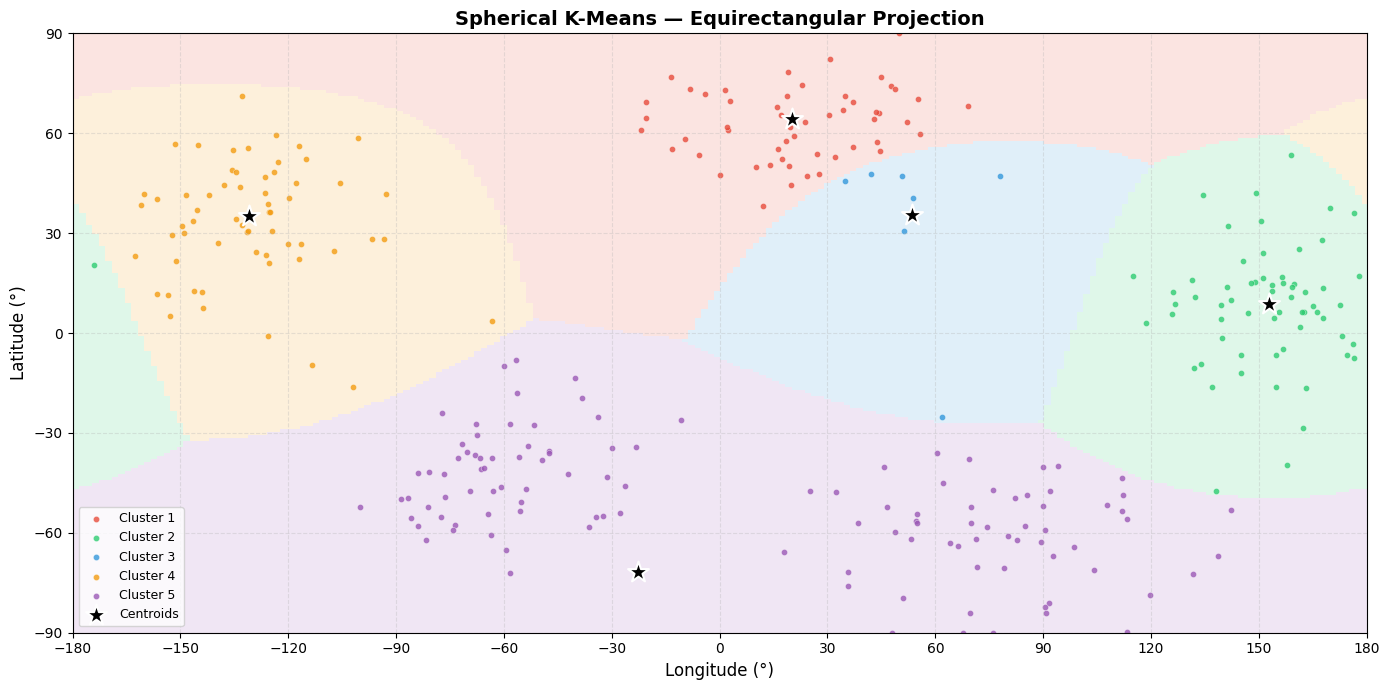

In [6]:
fig, ax = plt.subplots(figsize=(14, 7))

# Background: cluster territory shading via a dense grid
grid_res = 200
grid_lon = np.linspace(-np.pi, np.pi, grid_res)
grid_lat = np.linspace(-np.pi/2, np.pi/2, grid_res)
grid_lon_mesh, grid_lat_mesh = np.meshgrid(grid_lon, grid_lat)

grid_lats_flat = grid_lat_mesh.ravel()
grid_lons_flat = grid_lon_mesh.ravel()

# Assign each grid point to nearest centroid
grid_dists = haversine_distance_matrix(grid_lats_flat, grid_lons_flat, final_c_lats, final_c_lons, r=R)
grid_labels = np.argmin(grid_dists, axis=1).reshape(grid_res, grid_res)

# Create color map for shading
cmap_bg = mcolors.ListedColormap([mcolors.to_rgba(c, alpha=0.15) for c in cluster_colors])
ax.imshow(grid_labels, extent=[np.rad2deg(-np.pi), np.rad2deg(np.pi),
                                np.rad2deg(-np.pi/2), np.rad2deg(np.pi/2)],
          origin='lower', aspect='auto', cmap=cmap_bg, interpolation='nearest')

# Plot data points
for i in range(K):
    mask = pred_labels == i
    ax.scatter(np.rad2deg(lons[mask]), np.rad2deg(lats[mask]),
               c=cluster_colors[i], s=20, alpha=0.8, edgecolors='white',
               linewidths=0.3, label=f'Cluster {i+1}')

# Plot centroids
ax.scatter(np.rad2deg(final_c_lons), np.rad2deg(final_c_lats),
           c='black', marker='*', s=250, edgecolors='white',
           linewidths=1.5, zorder=10, label='Centroids')

# Grid lines like a map
ax.set_xticks(np.arange(-180, 181, 30))
ax.set_yticks(np.arange(-90, 91, 30))
ax.grid(True, alpha=0.3, linestyle='--')

ax.set_xlabel('Longitude (°)', fontsize=12)
ax.set_ylabel('Latitude (°)', fontsize=12)
ax.set_title('Spherical K-Means — Equirectangular Projection', fontsize=14, fontweight='bold')
ax.legend(loc='lower left', fontsize=9)

plt.tight_layout()
plt.show()

### 5c. Convergence Plot

Shows how the total intra-cluster Haversine distance decreases with each K-means iteration.

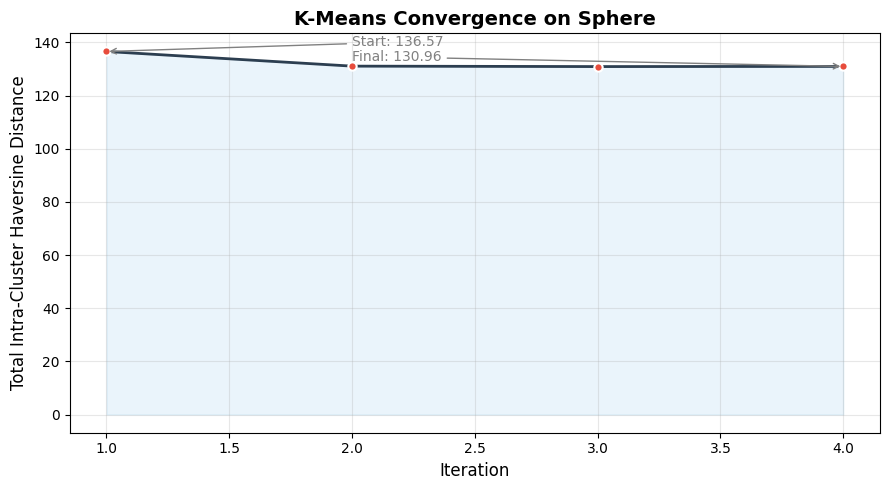

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))

iterations = range(1, len(cost_history) + 1)

ax.plot(iterations, cost_history, 'o-', color='#2c3e50', markersize=6,
        linewidth=2, markerfacecolor='#e74c3c', markeredgecolor='white', markeredgewidth=1.5)

ax.fill_between(iterations, cost_history, alpha=0.1, color='#3498db')

ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Total Intra-Cluster Haversine Distance', fontsize=12)
ax.set_title('K-Means Convergence on Sphere', fontsize=14, fontweight='bold')

# Annotate start and end
ax.annotate(f'Start: {cost_history[0]:.2f}', xy=(1, cost_history[0]),
            xytext=(2, cost_history[0] + 2),
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=10, color='gray')
ax.annotate(f'Final: {cost_history[-1]:.2f}', xy=(len(cost_history), cost_history[-1]),
            xytext=(len(cost_history) - 2, cost_history[-1] + 2),
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=10, color='gray')

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Summary

| Aspect | Standard K-Means | Spherical K-Means |
|--------|-----------------|-------------------|
| **Surface** | Flat (Euclidean space) | Sphere |
| **Distance** | Euclidean: $\sqrt{\sum(x_i - y_i)^2}$ | Haversine (great-circle) |
| **Centroid** | Arithmetic mean | Spherical mean (Cartesian avg → re-project) |
| **Use case** | General tabular data | GPS, astronomy, geospatial data |

### Key Takeaways
- The Haversine distance respects the curvature of the sphere, giving meaningful distances especially for points far apart.
- The spherical mean ensures centroids remain *on* the sphere surface rather than falling inside it.
- This approach naturally extends to any application involving latitude/longitude data (city clustering, satellite tracking, etc.).

---
# Part II: Alternative Distances on Spherical & Ellipsoidal Surfaces

Now that we've established Haversine as our baseline, let's explore **two more distance metrics** and see how they compare for clustering the same data.

## 7. Vincenty Distance (Ellipsoid)

Earth isn't a perfect sphere — it's an **oblate ellipsoid**, slightly squashed at the poles and bulging at the equator.

The **Vincenty formula** accounts for this by computing geodesic distance on an ellipsoid (WGS-84 standard):
- Semi-major axis: $a = 6{,}378{,}137$ m (equatorial radius)
- Flattening: $f = 1/298.257223563$

Unlike Haversine (closed-form), Vincenty is an **iterative algorithm** — it refines its answer over multiple steps until convergence.

**Analogy:** If Haversine measures distance on a basketball, Vincenty measures distance on a slightly deflated basketball that's wider around the middle.

In [8]:
def vincenty_distance(lat1, lon1, lat2, lon2, a=6_378_137.0, f=1/298.257223563, max_iter=200, tol=1e-12):
    """
    Vincenty's formula for geodesic distance on an ellipsoid.
    
    Inputs in radians. Returns distance in meters.
    Works element-wise when inputs are arrays.
    """
    b = a * (1 - f)  # semi-minor axis
    
    # Reduced latitudes
    U1 = np.arctan((1 - f) * np.tan(lat1))
    U2 = np.arctan((1 - f) * np.tan(lat2))
    sin_U1, cos_U1 = np.sin(U1), np.cos(U1)
    sin_U2, cos_U2 = np.sin(U2), np.cos(U2)
    
    L = lon2 - lon1
    lam = L.copy() if isinstance(L, np.ndarray) else float(L)
    
    for _ in range(max_iter):
        sin_lam = np.sin(lam)
        cos_lam = np.cos(lam)
        
        sin_sigma = np.sqrt(
            (cos_U2 * sin_lam)**2 +
            (cos_U1 * sin_U2 - sin_U1 * cos_U2 * cos_lam)**2
        )
        
        # Handle coincident points
        if np.any(sin_sigma == 0):
            if isinstance(sin_sigma, np.ndarray):
                sin_sigma = np.where(sin_sigma == 0, 1e-30, sin_sigma)
            else:
                return 0.0
        
        cos_sigma = sin_U1 * sin_U2 + cos_U1 * cos_U2 * cos_lam
        sigma = np.arctan2(sin_sigma, cos_sigma)
        
        sin_alpha = cos_U1 * cos_U2 * sin_lam / sin_sigma
        cos2_alpha = 1 - sin_alpha**2
        
        # Handle equatorial lines
        cos2_alpha = np.where(cos2_alpha == 0, 1e-30, cos2_alpha) if isinstance(cos2_alpha, np.ndarray) else max(cos2_alpha, 1e-30)
        
        cos_2sigma_m = cos_sigma - 2 * sin_U1 * sin_U2 / cos2_alpha
        
        C = f / 16 * cos2_alpha * (4 + f * (4 - 3 * cos2_alpha))
        
        lam_prev = lam
        lam = L + (1 - C) * f * sin_alpha * (
            sigma + C * sin_sigma * (
                cos_2sigma_m + C * cos_sigma * (-1 + 2 * cos_2sigma_m**2)
            )
        )
        
        diff = np.abs(lam - lam_prev)
        if np.all(diff < tol):
            break
    
    u2 = cos2_alpha * (a**2 - b**2) / b**2
    A_coeff = 1 + u2 / 16384 * (4096 + u2 * (-768 + u2 * (320 - 175 * u2)))
    B_coeff = u2 / 1024 * (256 + u2 * (-128 + u2 * (74 - 47 * u2)))
    
    delta_sigma = B_coeff * sin_sigma * (
        cos_2sigma_m + B_coeff / 4 * (
            cos_sigma * (-1 + 2 * cos_2sigma_m**2) -
            B_coeff / 6 * cos_2sigma_m * (-3 + 4 * sin_sigma**2) * (-3 + 4 * cos_2sigma_m**2)
        )
    )
    
    return b * A_coeff * (sigma - delta_sigma)


def vincenty_distance_matrix(lats, lons, center_lats, center_lons):
    """Compute distance matrix (in meters) between all points and all centers."""
    n_points = len(lats)
    n_centers = len(center_lats)
    dist_matrix = np.zeros((n_points, n_centers))
    
    for j in range(n_centers):
        dist_matrix[:, j] = vincenty_distance(lats, lons, center_lats[j], center_lons[j])
    
    return dist_matrix


# Sanity check: distance from equator/prime-meridian to equator/90°E
# Should be ~10,018 km (quarter of equatorial circumference)
d_vincenty = vincenty_distance(0, 0, 0, np.pi/2)
print(f"Vincenty: Equator 0°→90°E = {d_vincenty/1000:.1f} km  (expected: ~10,018 km)")

# Compare with Haversine on a sphere of Earth's mean radius
R_earth = 6_371_000  # meters
d_haversine_earth = haversine(0, 0, 0, np.pi/2, r=R_earth)
print(f"Haversine: Equator 0°→90°E = {d_haversine_earth/1000:.1f} km")
print(f"Difference: {abs(d_vincenty - d_haversine_earth)/1000:.2f} km")

Vincenty: Equator 0°→90°E = 10018.8 km  (expected: ~10,018 km)
Haversine: Equator 0°→90°E = 10007.5 km
Difference: 11.21 km


In [9]:
def ellipsoidal_mean(lats, lons):
    """
    Compute mean on ellipsoid by averaging in Cartesian space
    and projecting back. For small clusters this is a good approximation.
    (Exact ellipsoidal mean requires iterative Karcher mean — overkill here.)
    """
    # Use spherical mean as approximation — works well for small clusters
    return spherical_mean(lats, lons)


def vincenty_kmeans(lats, lons, k=5, max_iter=100, tol=1e-6, seed=123):
    """
    K-means clustering using Vincenty (ellipsoidal) distance.
    """
    rng = np.random.default_rng(seed)
    n = len(lats)
    
    init_indices = rng.choice(n, size=k, replace=False)
    c_lats = lats[init_indices].copy()
    c_lons = lons[init_indices].copy()
    
    history = []
    labels = np.zeros(n, dtype=int)
    
    for iteration in range(max_iter):
        dist_matrix = vincenty_distance_matrix(lats, lons, c_lats, c_lons)
        labels = np.argmin(dist_matrix, axis=1)
        
        total_dist = sum(dist_matrix[i, labels[i]] for i in range(n))
        history.append(total_dist)
        
        new_c_lats = np.zeros(k)
        new_c_lons = np.zeros(k)
        for j in range(k):
            members = labels == j
            if np.sum(members) == 0:
                rand_idx = rng.choice(n)
                new_c_lats[j] = lats[rand_idx]
                new_c_lons[j] = lons[rand_idx]
            else:
                new_c_lats[j], new_c_lons[j] = ellipsoidal_mean(lats[members], lons[members])
        
        centroid_shift = haversine(c_lats, c_lons, new_c_lats, new_c_lons, r=1.0)
        c_lats = new_c_lats
        c_lons = new_c_lons
        
        if np.max(centroid_shift) < tol:
            print(f"Vincenty K-Means converged at iteration {iteration + 1}")
            break
    else:
        print(f"Vincenty K-Means reached max iterations ({max_iter})")
    
    return labels, c_lats, c_lons, history


# Run Vincenty K-means
vincenty_labels, vincenty_c_lats, vincenty_c_lons, vincenty_history = vincenty_kmeans(
    lats, lons, k=K, max_iter=100
)

print(f"Cluster sizes: {[np.sum(vincenty_labels == i) for i in range(K)]}")

Vincenty K-Means converged at iteration 4
Cluster sizes: [np.int64(54), np.int64(63), np.int64(7), np.int64(61), np.int64(115)]


### 7a. Vincenty Clustering — 3D Ellipsoid Plot

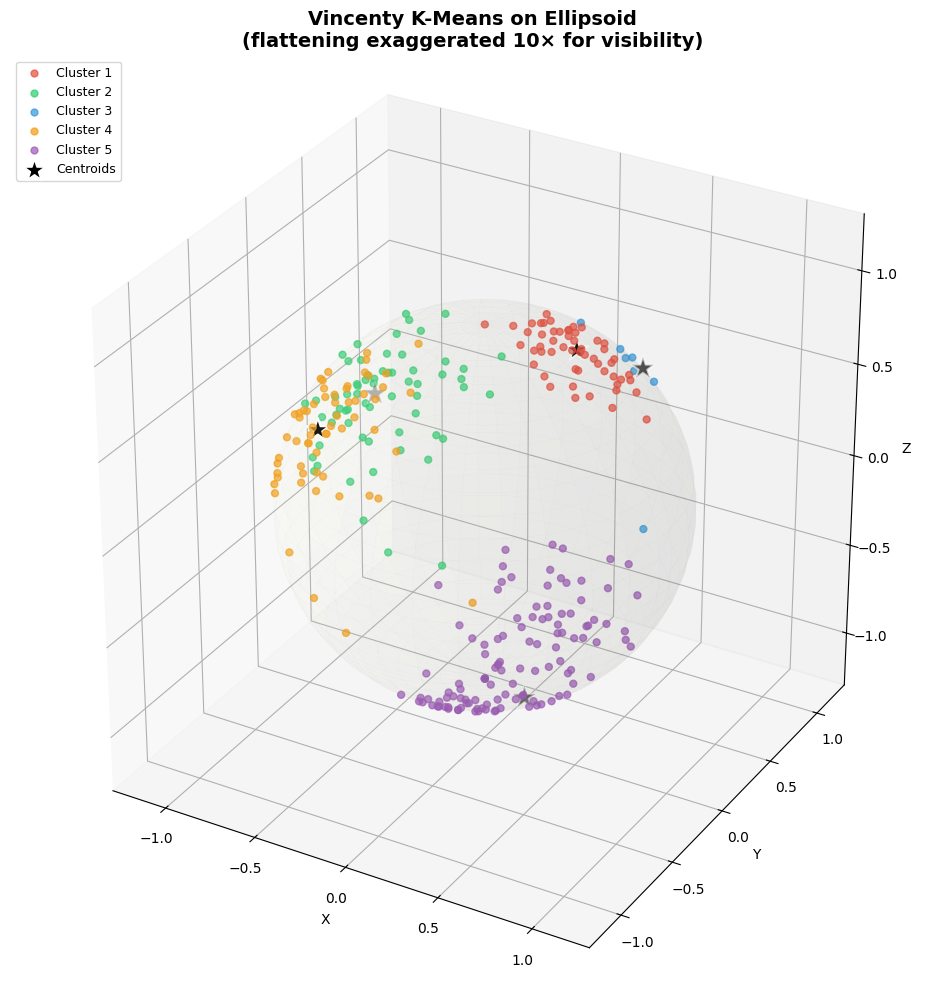

In [10]:
# WGS-84 ellipsoid parameters (scaled down for visualization)
a_vis = 1.0          # semi-major (equatorial)
f_vis = 1/298.257    # flattening
b_vis = a_vis * (1 - f_vis)  # semi-minor (polar)

# Exaggerate flattening for visibility (10x)
b_vis_exag = a_vis * (1 - 10 * f_vis)

def latlon_to_ellipsoid(lat, lon, a=a_vis, b=b_vis_exag):
    """Convert lat/lon to 3D point on an ellipsoid."""
    x = a * np.cos(lat) * np.cos(lon)
    y = a * np.cos(lat) * np.sin(lon)
    z = b * np.sin(lat)
    return x, y, z


# Ellipsoid wireframe
phi_grid = np.linspace(0, 2 * np.pi, 60)
theta_grid = np.linspace(-np.pi/2, np.pi/2, 30)
phi_m, theta_m = np.meshgrid(phi_grid, theta_grid)
xe = a_vis * np.cos(theta_m) * np.cos(phi_m)
ye = a_vis * np.cos(theta_m) * np.sin(phi_m)
ze = b_vis_exag * np.sin(theta_m)

# Points on ellipsoid
epx, epy, epz = latlon_to_ellipsoid(lats, lons)
ecx, ecy, ecz = latlon_to_ellipsoid(vincenty_c_lats, vincenty_c_lons)

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(xe, ye, ze, alpha=0.05, color='lightyellow', edgecolor='gray', linewidth=0.1)

for i in range(K):
    mask = vincenty_labels == i
    ax.scatter(epx[mask], epy[mask], epz[mask],
               c=cluster_colors[i], s=25, alpha=0.7, label=f'Cluster {i+1}', depthshade=True)

ax.scatter(ecx, ecy, ecz, c='black', marker='*', s=300, edgecolors='white',
           linewidths=1.5, zorder=10, label='Centroids')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Vincenty K-Means on Ellipsoid\n(flattening exaggerated 10× for visibility)',
             fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax.set_xlim([-1.3, 1.3]); ax.set_ylim([-1.3, 1.3]); ax.set_zlim([-1.3, 1.3])
ax.set_box_aspect([1, 1, 1])

plt.tight_layout()
plt.show()

### 7b. Vincenty Clustering — 2D Map Projection

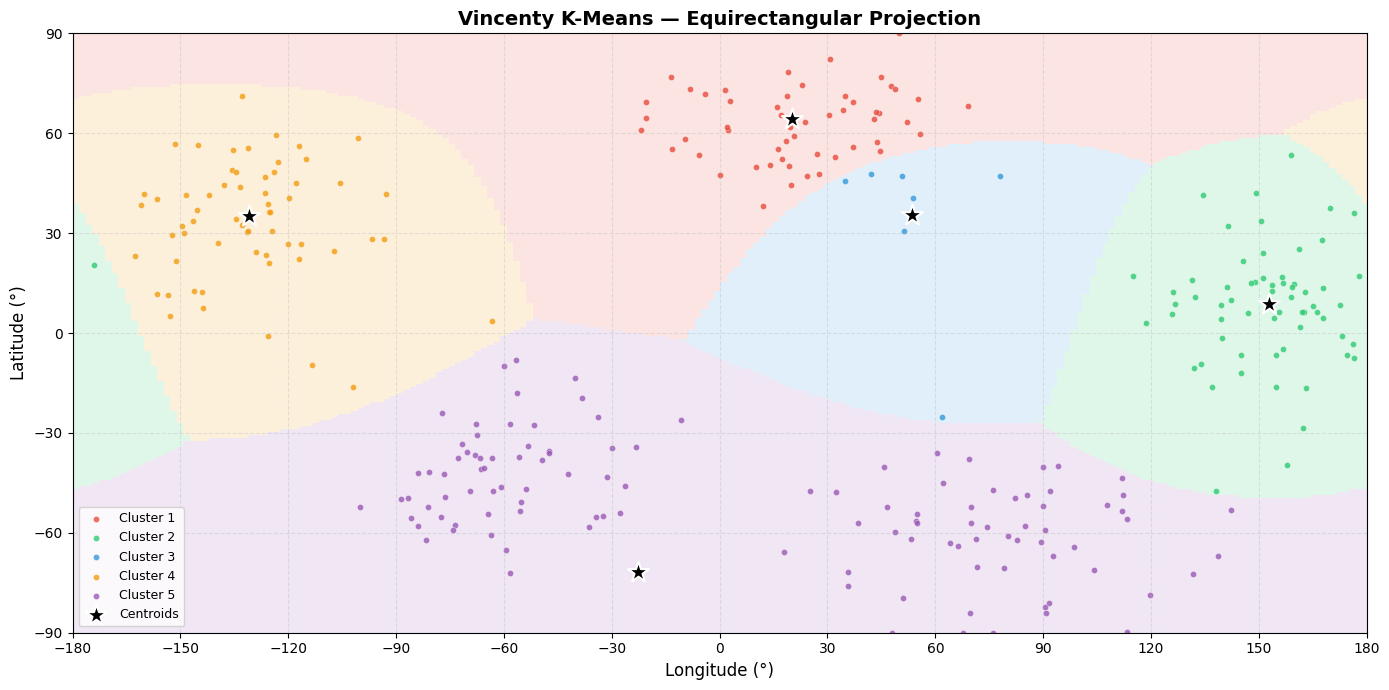

In [11]:
fig, ax = plt.subplots(figsize=(14, 7))

# Background territory shading
# (Use Haversine-based grid for speed — Vincenty would be very slow on 40k grid points)
grid_dists_v = haversine_distance_matrix(grid_lats_flat, grid_lons_flat, vincenty_c_lats, vincenty_c_lons, r=R)
grid_labels_v = np.argmin(grid_dists_v, axis=1).reshape(grid_res, grid_res)

cmap_bg = mcolors.ListedColormap([mcolors.to_rgba(c, alpha=0.15) for c in cluster_colors])
ax.imshow(grid_labels_v, extent=[-180, 180, -90, 90],
          origin='lower', aspect='auto', cmap=cmap_bg, interpolation='nearest')

for i in range(K):
    mask = vincenty_labels == i
    ax.scatter(np.rad2deg(lons[mask]), np.rad2deg(lats[mask]),
               c=cluster_colors[i], s=20, alpha=0.8, edgecolors='white',
               linewidths=0.3, label=f'Cluster {i+1}')

ax.scatter(np.rad2deg(vincenty_c_lons), np.rad2deg(vincenty_c_lats),
           c='black', marker='*', s=250, edgecolors='white',
           linewidths=1.5, zorder=10, label='Centroids')

ax.set_xticks(np.arange(-180, 181, 30))
ax.set_yticks(np.arange(-90, 91, 30))
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xlabel('Longitude (°)', fontsize=12)
ax.set_ylabel('Latitude (°)', fontsize=12)
ax.set_title('Vincenty K-Means — Equirectangular Projection', fontsize=14, fontweight='bold')
ax.legend(loc='lower left', fontsize=9)
plt.tight_layout()
plt.show()

## 8. Cosine Distance (Sphere)

**Cosine distance** measures the *angle* between two vectors from the origin (center of sphere) to the surface points. For unit vectors:

$$d_{\cos}(\mathbf{u}, \mathbf{v}) = 1 - \cos(\theta) = 1 - \mathbf{u} \cdot \mathbf{v}$$

This is **not** a geodesic distance — it doesn't measure along the surface. Instead, it captures the *angular separation* between directions.

**Why it matters:** Cosine distance is the standard metric for text/NLP embeddings (TF-IDF, word2vec, BERT), where data naturally lives on a high-dimensional unit sphere. Using it on our 3D sphere shows the same principle in a visual setting.

**Relationship to Haversine:** For small angles, cosine distance ≈ scaled Haversine. They diverge as points get farther apart.

In [12]:
def cosine_distance(lat1, lon1, lat2, lon2):
    """
    Cosine distance between two points on a unit sphere.
    d = 1 - cos(angle) = 1 - dot(u, v)  for unit vectors.
    """
    x1, y1, z1 = latlon_to_cartesian(lat1, lon1, r=1.0)
    x2, y2, z2 = latlon_to_cartesian(lat2, lon2, r=1.0)
    dot = x1 * x2 + y1 * y2 + z1 * z2
    # Clip for numerical stability
    dot = np.clip(dot, -1, 1)
    return 1.0 - dot


def cosine_distance_matrix(lats, lons, center_lats, center_lons):
    """Compute cosine distance matrix between all points and all centers."""
    n_points = len(lats)
    n_centers = len(center_lats)
    dist_matrix = np.zeros((n_points, n_centers))
    
    for j in range(n_centers):
        dist_matrix[:, j] = cosine_distance(lats, lons, center_lats[j], center_lons[j])
    
    return dist_matrix


# Sanity checks
d_same = cosine_distance(0.5, 1.0, 0.5, 1.0)
d_ortho = cosine_distance(0, 0, np.pi/2, 0)       # 90° apart → cosine dist = 1
d_anti = cosine_distance(0, 0, 0, np.pi)           # 180° apart → cosine dist = 2

print(f"Same point:      cosine dist = {d_same:.4f}  (expected: 0.0)")
print(f"90° apart:       cosine dist = {d_ortho:.4f}  (expected: 1.0)")
print(f"Antipodal (180°): cosine dist = {d_anti:.4f}  (expected: 2.0)")

Same point:      cosine dist = 0.0000  (expected: 0.0)
90° apart:       cosine dist = 1.0000  (expected: 1.0)
Antipodal (180°): cosine dist = 2.0000  (expected: 2.0)


In [13]:
def cosine_kmeans(lats, lons, k=5, max_iter=100, tol=1e-6, seed=123):
    """
    K-means clustering using cosine distance.
    Centroid update: average Cartesian vectors, normalize back to unit sphere.
    """
    rng = np.random.default_rng(seed)
    n = len(lats)
    
    init_indices = rng.choice(n, size=k, replace=False)
    c_lats = lats[init_indices].copy()
    c_lons = lons[init_indices].copy()
    
    history = []
    labels = np.zeros(n, dtype=int)
    
    for iteration in range(max_iter):
        dist_matrix = cosine_distance_matrix(lats, lons, c_lats, c_lons)
        labels = np.argmin(dist_matrix, axis=1)
        
        total_dist = sum(dist_matrix[i, labels[i]] for i in range(n))
        history.append(total_dist)
        
        new_c_lats = np.zeros(k)
        new_c_lons = np.zeros(k)
        for j in range(k):
            members = labels == j
            if np.sum(members) == 0:
                rand_idx = rng.choice(n)
                new_c_lats[j] = lats[rand_idx]
                new_c_lons[j] = lons[rand_idx]
            else:
                # Mean-and-normalize (same as spherical mean for unit sphere)
                new_c_lats[j], new_c_lons[j] = spherical_mean(lats[members], lons[members])
        
        centroid_shift = cosine_distance(c_lats, c_lons, new_c_lats, new_c_lons)
        c_lats = new_c_lats
        c_lons = new_c_lons
        
        if np.max(centroid_shift) < tol:
            print(f"Cosine K-Means converged at iteration {iteration + 1}")
            break
    else:
        print(f"Cosine K-Means reached max iterations ({max_iter})")
    
    return labels, c_lats, c_lons, history


# Run Cosine K-means
cosine_labels, cosine_c_lats, cosine_c_lons, cosine_history = cosine_kmeans(
    lats, lons, k=K, max_iter=100
)

print(f"Cluster sizes: {[np.sum(cosine_labels == i) for i in range(K)]}")

Cosine K-Means converged at iteration 4
Cluster sizes: [np.int64(54), np.int64(63), np.int64(7), np.int64(61), np.int64(115)]


### 8a. Cosine K-Means — 3D Sphere Plot

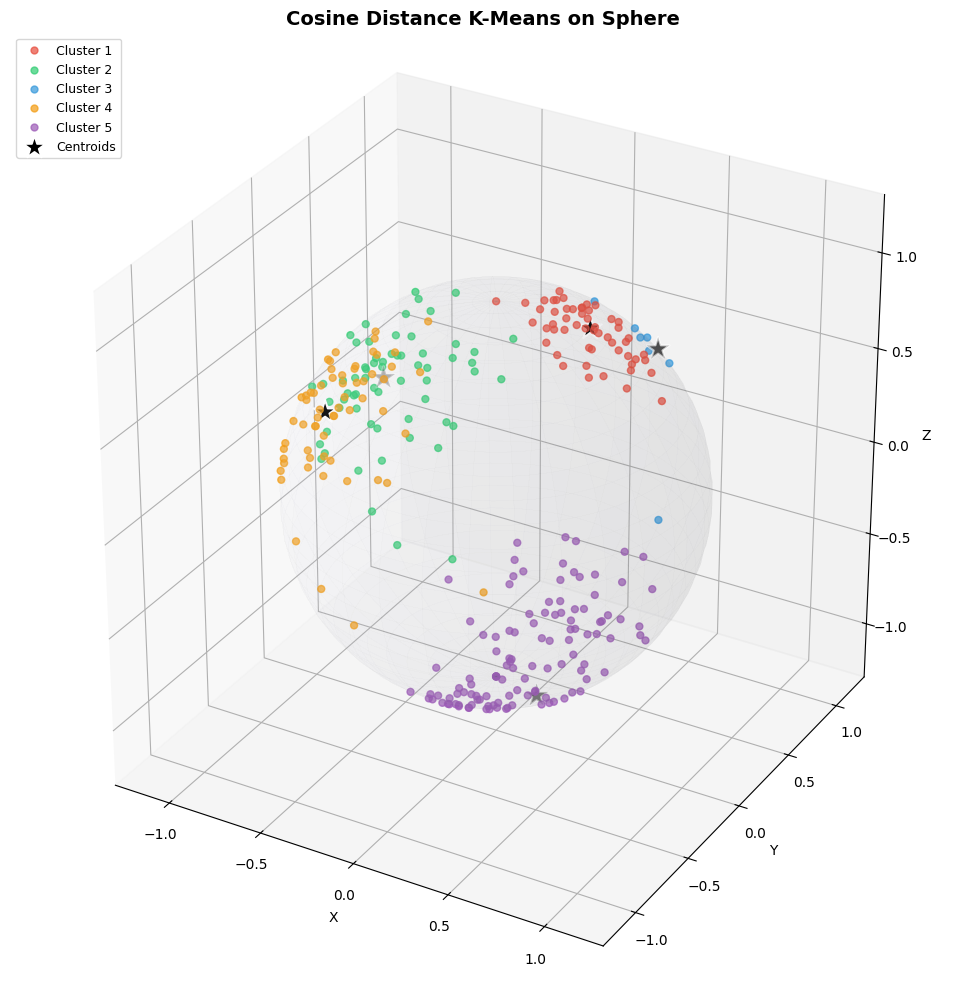

In [14]:
cos_cx, cos_cy, cos_cz = latlon_to_cartesian(cosine_c_lats, cosine_c_lons)

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(xs, ys, zs, alpha=0.05, color='lavender', edgecolor='gray', linewidth=0.1)

for i in range(K):
    mask = cosine_labels == i
    ax.scatter(px[mask], py[mask], pz[mask],
               c=cluster_colors[i], s=25, alpha=0.7, label=f'Cluster {i+1}', depthshade=True)

ax.scatter(cos_cx, cos_cy, cos_cz, c='black', marker='*', s=300, edgecolors='white',
           linewidths=1.5, zorder=10, label='Centroids')

ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.set_title('Cosine Distance K-Means on Sphere', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax.set_xlim([-1.3, 1.3]); ax.set_ylim([-1.3, 1.3]); ax.set_zlim([-1.3, 1.3])
ax.set_box_aspect([1, 1, 1])
plt.tight_layout()
plt.show()

### 8b. Cosine K-Means — 2D Map Projection

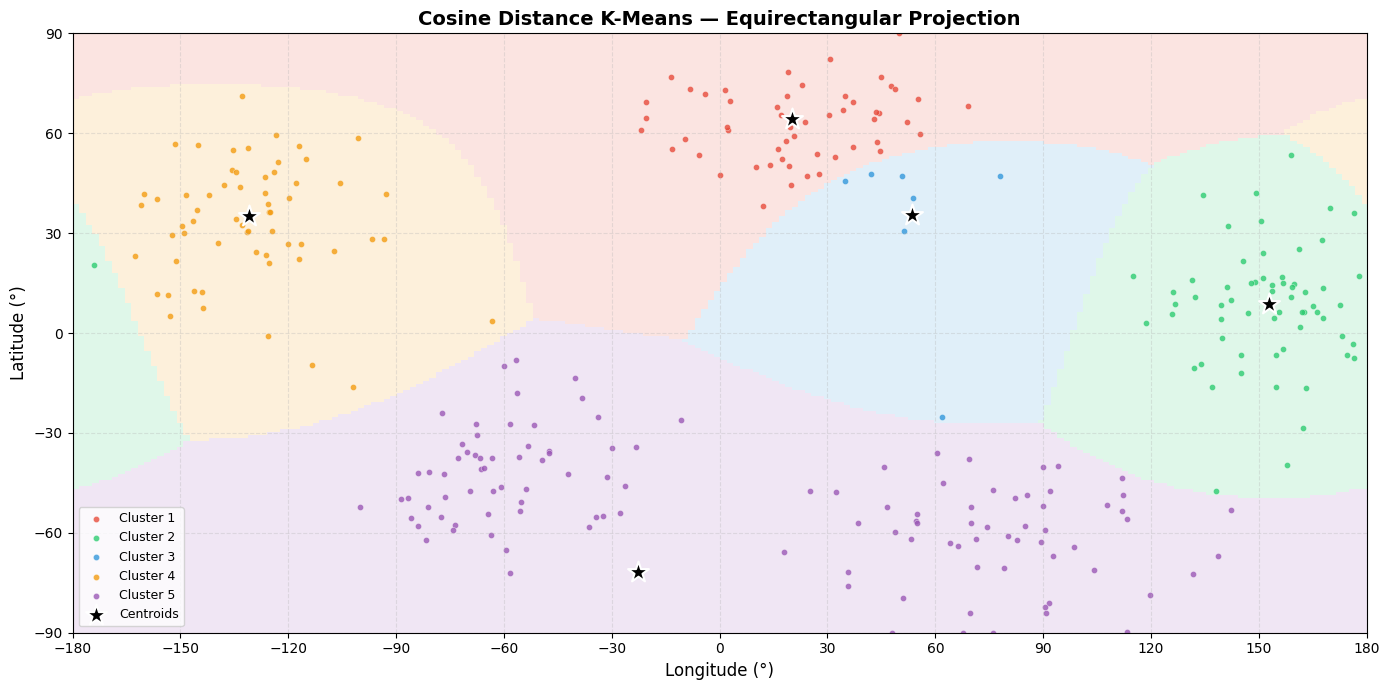

In [15]:
fig, ax = plt.subplots(figsize=(14, 7))

grid_dists_c = cosine_distance_matrix(grid_lats_flat, grid_lons_flat, cosine_c_lats, cosine_c_lons)
grid_labels_c = np.argmin(grid_dists_c, axis=1).reshape(grid_res, grid_res)

cmap_bg = mcolors.ListedColormap([mcolors.to_rgba(c, alpha=0.15) for c in cluster_colors])
ax.imshow(grid_labels_c, extent=[-180, 180, -90, 90],
          origin='lower', aspect='auto', cmap=cmap_bg, interpolation='nearest')

for i in range(K):
    mask = cosine_labels == i
    ax.scatter(np.rad2deg(lons[mask]), np.rad2deg(lats[mask]),
               c=cluster_colors[i], s=20, alpha=0.8, edgecolors='white',
               linewidths=0.3, label=f'Cluster {i+1}')

ax.scatter(np.rad2deg(cosine_c_lons), np.rad2deg(cosine_c_lats),
           c='black', marker='*', s=250, edgecolors='white',
           linewidths=1.5, zorder=10, label='Centroids')

ax.set_xticks(np.arange(-180, 181, 30))
ax.set_yticks(np.arange(-90, 91, 30))
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xlabel('Longitude (°)', fontsize=12)
ax.set_ylabel('Latitude (°)', fontsize=12)
ax.set_title('Cosine Distance K-Means — Equirectangular Projection', fontsize=14, fontweight='bold')
ax.legend(loc='lower left', fontsize=9)
plt.tight_layout()
plt.show()

---
## 9. Distance Comparison Dashboard

Now let's put all three methods side by side to see where they agree and where they diverge.

### 9a. Side-by-Side 2D Map Projections

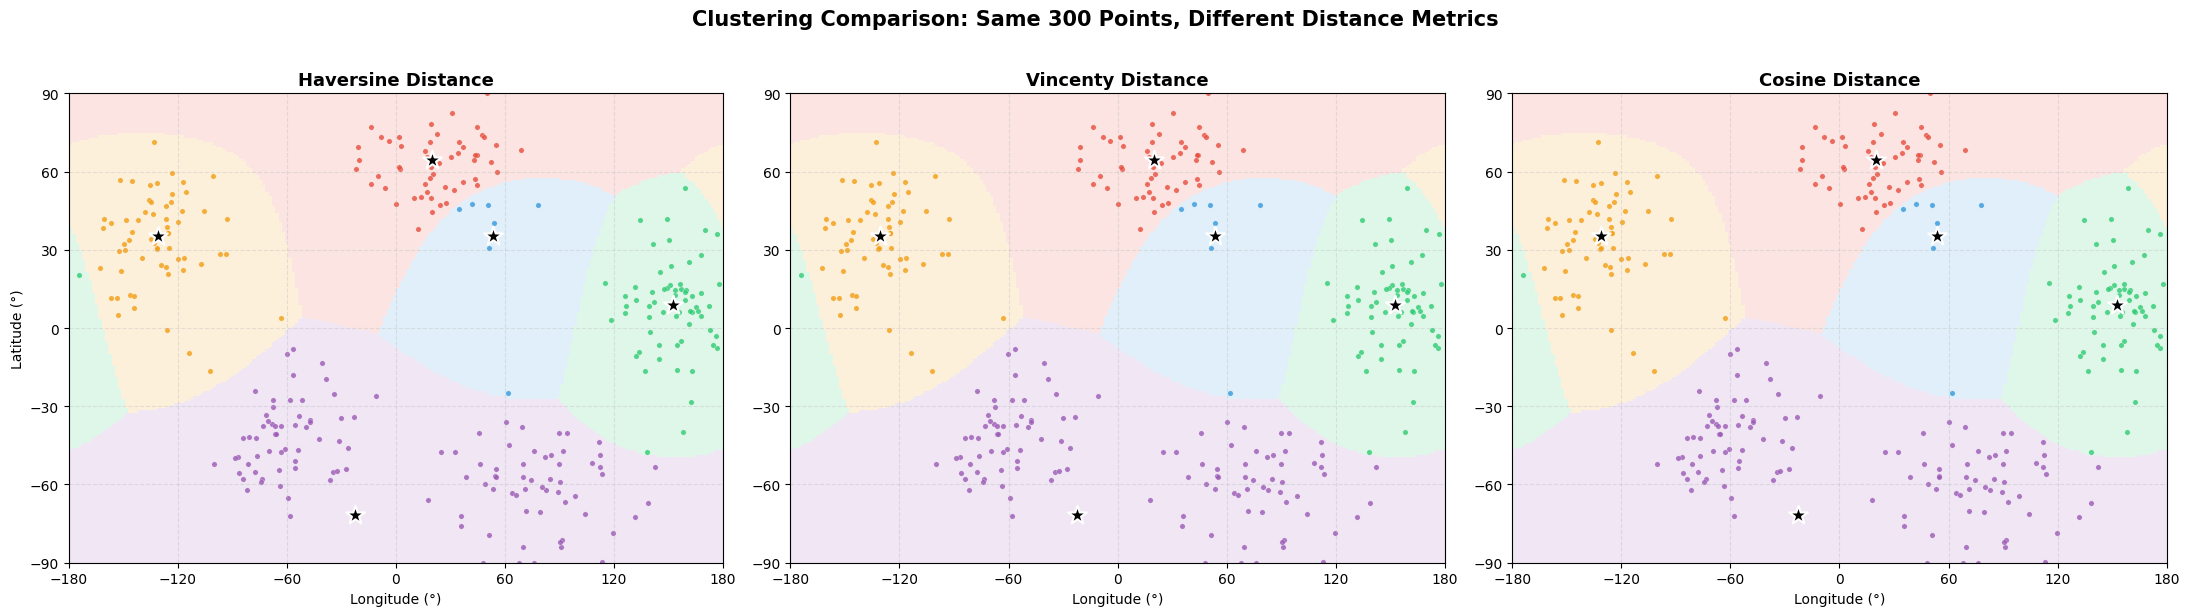

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

all_results = [
    ('Haversine', pred_labels, final_c_lats, final_c_lons),
    ('Vincenty',  vincenty_labels, vincenty_c_lats, vincenty_c_lons),
    ('Cosine',    cosine_labels, cosine_c_lats, cosine_c_lons),
]

cmap_bg = mcolors.ListedColormap([mcolors.to_rgba(c, alpha=0.15) for c in cluster_colors])

for idx, (name, lbls, c_la, c_lo) in enumerate(all_results):
    ax = axes[idx]
    
    # Territory shading
    if name == 'Vincenty':
        # Use Haversine grid assignment with Vincenty centroids (speed)
        g_d = haversine_distance_matrix(grid_lats_flat, grid_lons_flat, c_la, c_lo, r=R)
    elif name == 'Cosine':
        g_d = cosine_distance_matrix(grid_lats_flat, grid_lons_flat, c_la, c_lo)
    else:
        g_d = haversine_distance_matrix(grid_lats_flat, grid_lons_flat, c_la, c_lo, r=R)
    
    g_l = np.argmin(g_d, axis=1).reshape(grid_res, grid_res)
    ax.imshow(g_l, extent=[-180, 180, -90, 90], origin='lower', aspect='auto',
              cmap=cmap_bg, interpolation='nearest')
    
    for i in range(K):
        mask = lbls == i
        ax.scatter(np.rad2deg(lons[mask]), np.rad2deg(lats[mask]),
                   c=cluster_colors[i], s=15, alpha=0.8, edgecolors='white', linewidths=0.2)
    
    ax.scatter(np.rad2deg(c_lo), np.rad2deg(c_la),
               c='black', marker='*', s=200, edgecolors='white', linewidths=1.5, zorder=10)
    
    ax.set_xticks(np.arange(-180, 181, 60))
    ax.set_yticks(np.arange(-90, 91, 30))
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_title(f'{name} Distance', fontsize=13, fontweight='bold')
    ax.set_xlabel('Longitude (°)')
    if idx == 0:
        ax.set_ylabel('Latitude (°)')

plt.suptitle('Clustering Comparison: Same 300 Points, Different Distance Metrics',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 9b. Agreement Analysis

In [17]:
from itertools import combinations

def cluster_agreement(labels_a, labels_b):
    """
    Compute agreement between two clusterings using the Rand Index approach:
    fraction of point pairs that are either in the same cluster in both,
    or in different clusters in both.
    """
    n = len(labels_a)
    agree = 0
    total = 0
    for i, j in combinations(range(n), 2):
        same_a = labels_a[i] == labels_a[j]
        same_b = labels_b[i] == labels_b[j]
        if same_a == same_b:
            agree += 1
        total += 1
    return agree / total


# Compute pairwise agreement (Rand Index)
methods = ['Haversine', 'Vincenty', 'Cosine']
all_labels = [pred_labels, vincenty_labels, cosine_labels]

print("Pairwise Clustering Agreement (Rand Index)")
print("=" * 50)

agreement_data = {}
for i in range(3):
    for j in range(i+1, 3):
        ri = cluster_agreement(all_labels[i], all_labels[j])
        agreement_data[(methods[i], methods[j])] = ri
        print(f"  {methods[i]:12s} vs {methods[j]:12s}  →  {ri:.4f}  ({ri*100:.1f}%)")

# Also show how many individual points changed cluster
print(f"\nPoints with DIFFERENT assignments:")
print(f"  Haversine vs Vincenty: {np.sum(pred_labels != vincenty_labels):3d} / {len(pred_labels)} "
      f"({np.sum(pred_labels != vincenty_labels)/len(pred_labels)*100:.1f}%)")
print(f"  Haversine vs Cosine:   {np.sum(pred_labels != cosine_labels):3d} / {len(pred_labels)} "
      f"({np.sum(pred_labels != cosine_labels)/len(pred_labels)*100:.1f}%)")
print(f"  Vincenty  vs Cosine:   {np.sum(vincenty_labels != cosine_labels):3d} / {len(pred_labels)} "
      f"({np.sum(vincenty_labels != cosine_labels)/len(pred_labels)*100:.1f}%)")

print(f"\n💡 Note: Cluster label numbers may differ even when assignments are identical.")
print(f"   The Rand Index accounts for this by comparing pair-level groupings.")

Pairwise Clustering Agreement (Rand Index)
  Haversine    vs Vincenty      →  1.0000  (100.0%)
  Haversine    vs Cosine        →  1.0000  (100.0%)
  Vincenty     vs Cosine        →  1.0000  (100.0%)

Points with DIFFERENT assignments:
  Haversine vs Vincenty:   0 / 300 (0.0%)
  Haversine vs Cosine:     0 / 300 (0.0%)
  Vincenty  vs Cosine:     0 / 300 (0.0%)

💡 Note: Cluster label numbers may differ even when assignments are identical.
   The Rand Index accounts for this by comparing pair-level groupings.


### 9c. Pairwise Distance Scatter: How the Metrics Relate

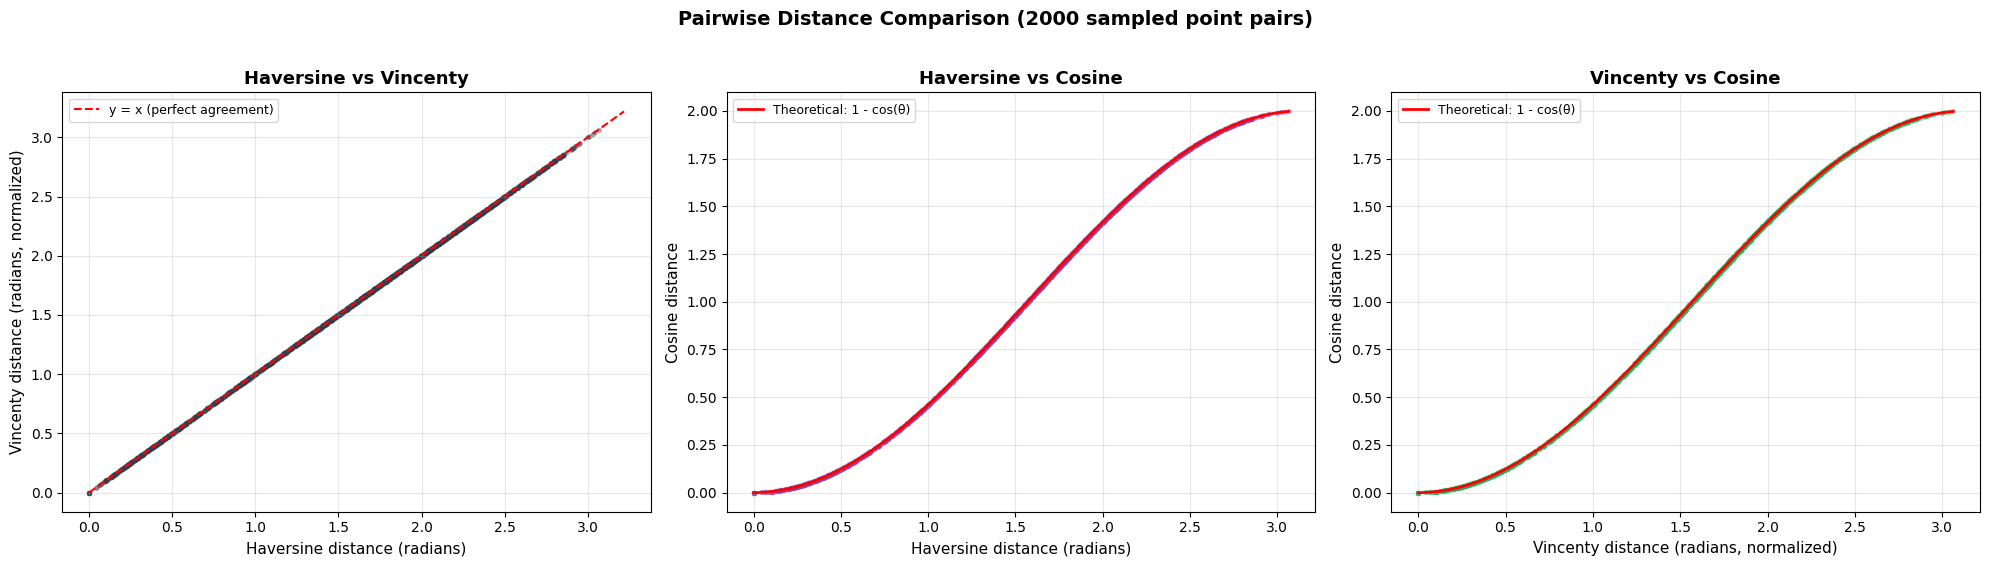

In [18]:
# Sample point pairs for distance comparison (full pairwise would be 300*299/2 = 44,850)
rng_sample = np.random.default_rng(99)
n_pairs = 2000
idx_a = rng_sample.choice(len(lats), size=n_pairs)
idx_b = rng_sample.choice(len(lats), size=n_pairs)

# Compute all three distances for these pairs
d_hav = haversine(lats[idx_a], lons[idx_a], lats[idx_b], lons[idx_b], r=R)
d_vin = vincenty_distance(lats[idx_a], lons[idx_a], lats[idx_b], lons[idx_b])
d_cos = cosine_distance(lats[idx_a], lons[idx_a], lats[idx_b], lons[idx_b])

# Normalize Vincenty to unit-sphere scale for fair comparison
# (Vincenty returns meters on Earth; scale to [0, pi] range like Haversine on unit sphere)
d_vin_norm = d_vin / 6_371_000  # convert to radians (approx arc length on unit sphere)

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

# 1. Haversine vs Vincenty (normalized)
axes[0].scatter(d_hav, d_vin_norm, alpha=0.3, s=8, c='#2c3e50')
lim = max(d_hav.max(), d_vin_norm.max()) * 1.05
axes[0].plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='y = x (perfect agreement)')
axes[0].set_xlabel('Haversine distance (radians)', fontsize=11)
axes[0].set_ylabel('Vincenty distance (radians, normalized)', fontsize=11)
axes[0].set_title('Haversine vs Vincenty', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# 2. Haversine vs Cosine
axes[1].scatter(d_hav, d_cos, alpha=0.3, s=8, c='#8e44ad')
# Theoretical curve: cosine_dist = 1 - cos(haversine_dist) for unit sphere
hav_range = np.linspace(0, d_hav.max(), 200)
cos_theoretical = 1 - np.cos(hav_range)
axes[1].plot(hav_range, cos_theoretical, 'r-', linewidth=2, label='Theoretical: 1 - cos(θ)')
axes[1].set_xlabel('Haversine distance (radians)', fontsize=11)
axes[1].set_ylabel('Cosine distance', fontsize=11)
axes[1].set_title('Haversine vs Cosine', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# 3. Vincenty (normalized) vs Cosine
axes[2].scatter(d_vin_norm, d_cos, alpha=0.3, s=8, c='#27ae60')
vin_range = np.linspace(0, d_vin_norm.max(), 200)
cos_theoretical_2 = 1 - np.cos(vin_range)
axes[2].plot(vin_range, cos_theoretical_2, 'r-', linewidth=2, label='Theoretical: 1 - cos(θ)')
axes[2].set_xlabel('Vincenty distance (radians, normalized)', fontsize=11)
axes[2].set_ylabel('Cosine distance', fontsize=11)
axes[2].set_title('Vincenty vs Cosine', fontsize=13, fontweight='bold')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.suptitle('Pairwise Distance Comparison (2000 sampled point pairs)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Choosing K — PVE & Silhouette Analysis

How do we know K = 5 is the right number of clusters? We use two metrics:

**PVE (Proportion of Variance Explained)**

$$\text{PVE}(K) = 1 - \frac{\text{TWCSS}_K}{\text{TWCSS}_1}$$

where $\text{TWCSS}_K$ is the **total within-cluster sum of squared distances** for K clusters and $\text{TWCSS}_1$ is the single-cluster baseline (all points assigned to one cluster). PVE ranges from 0 to 1; an "elbow" in the curve marks a natural K choice.

**Silhouette Score**

For each point $i$:

$$s(i) = \frac{b(i) - a(i)}{\max(a(i),\, b(i))} \in [-1, +1]$$

where $a(i)$ = mean distance to other points in the **same** cluster (cohesion), and $b(i)$ = mean distance to points in the **nearest other** cluster (separation). Computed from the precomputed pairwise distance matrix so it automatically respects this notebook's metric.

In [ ]:
def silhouette_from_matrix(D, labels):
    """
    Mean silhouette score from a precomputed N×N distance matrix.
    s(i) = (b(i) - a(i)) / max(a(i), b(i))
    """
    n = len(labels)
    unique_clusters = np.unique(labels)
    if len(unique_clusters) <= 1:
        return 0.0
    scores = np.zeros(n)
    for i in range(n):
        ci = labels[i]
        same_mask = (labels == ci).copy()
        same_mask[i] = False
        a_i = float(np.mean(D[i, same_mask])) if np.any(same_mask) else 0.0
        b_i = np.inf
        for cj in unique_clusters:
            if cj == ci:
                continue
            other_mask = (labels == cj)
            if np.any(other_mask):
                b_i = min(b_i, float(np.mean(D[i, other_mask])))
        denom = max(a_i, b_i)
        scores[i] = (b_i - a_i) / denom if denom > 1e-15 else 0.0
    return float(np.mean(scores))

In [ ]:
# Build full N×N Haversine distance matrix (uses the haversine() function already defined)
n_pts = len(lats)
print("Building pairwise Haversine distance matrix...")
D_full = np.zeros((n_pts, n_pts))
for i in range(n_pts):
    D_full[i] = haversine(lats[i], lons[i], lats, lons, r=R)

# TWCSS baseline: one cluster centred on the spherical mean of all points
overall_lat, overall_lon = spherical_mean(lats, lons)
TWCSS_1 = float(np.sum(haversine(lats, lons, overall_lat, overall_lon, r=R) ** 2))

K_range = range(2, 11)
pve_vals = []
sil_vals = []

print(f"{'K':>4} {'TWCSS':>10} {'PVE':>8} {'Silhouette':>12}")
print("-" * 38)
for k in K_range:
    lbls_k, c_lats_k, c_lons_k, _ = spherical_kmeans(lats, lons, k=k, max_iter=100)
    # Distance from each point to its assigned centroid
    dists_k = haversine(lats, lons, c_lats_k[lbls_k], c_lons_k[lbls_k], r=R)
    twcss_k = float(np.sum(dists_k ** 2))
    pve = 1 - twcss_k / TWCSS_1
    sil = silhouette_from_matrix(D_full, lbls_k)
    pve_vals.append(pve)
    sil_vals.append(sil)
    print(f"{k:>4} {twcss_k:>10.4f} {pve:>8.4f} {sil:>12.4f}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
K_chosen = 5
K_vals = list(K_range)

ax = axes[0]
ax.plot(K_vals, pve_vals, 'o-', color='#2c3e50', linewidth=2, markersize=7,
        markerfacecolor='#3498db', markeredgecolor='white', markeredgewidth=1.5)
ax.axvline(K_chosen, color='#e74c3c', linestyle='--', linewidth=1.8,
           label=f'Chosen K = {K_chosen}')
ax.fill_between(K_vals, pve_vals, alpha=0.08, color='#3498db')
ax.set_xlabel('Number of Clusters K', fontsize=12)
ax.set_ylabel('PVE', fontsize=12)
ax.set_title('PVE Elbow Curve', fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.set_xticks(K_vals); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(K_vals, sil_vals, 's-', color='#2c3e50', linewidth=2, markersize=7,
        markerfacecolor='#9b59b6', markeredgecolor='white', markeredgewidth=1.5)
best_k_sil = K_vals[int(np.argmax(sil_vals))]
ax.axvline(best_k_sil, color='#9b59b6', linestyle='--', linewidth=1.8,
           label=f'Best silhouette K = {best_k_sil}')
ax.axvline(K_chosen, color='#e74c3c', linestyle=':', linewidth=1.8,
           label=f'Chosen K = {K_chosen}')
ax.fill_between(K_vals, sil_vals, alpha=0.08, color='#9b59b6')
ax.set_xlabel('Number of Clusters K', fontsize=12)
ax.set_ylabel('Mean Silhouette Score', fontsize=12)
ax.set_title('Silhouette Score vs K', fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.set_xticks(K_vals); ax.grid(True, alpha=0.3)

plt.suptitle('Choosing K: PVE & Silhouette Validation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nK=2..10 summary:")
print(f"{'K':>4} {'PVE':>8} {'Silhouette':>12}")
print("-" * 27)
for k, pve, sil in zip(K_vals, pve_vals, sil_vals):
    marker = " ◄ chosen" if k == K_chosen else ""
    print(f"{k:>4} {pve:>8.4f} {sil:>12.4f}{marker}")

---
## 10. Complete Summary — Sphere & Ellipsoid Distances

| Metric | Surface | Formula Type | Range (unit sphere) | Speed | Best Use Case |
|--------|---------|-------------|--------------------:|-------|---------------|
| **Haversine** | Perfect sphere | Closed-form | [0, π] | ⚡ Fast | GPS clustering (quick & good) |
| **Vincenty** | Oblate ellipsoid (WGS-84) | Iterative | [0, ~π] | 🐢 Slow | Precision geospatial (surveying, navigation) |
| **Cosine** | Unit sphere (any dim) | Dot product | [0, 2] | ⚡⚡ Fastest | NLP / embedding clustering |

### Key Takeaways

1. **Haversine vs Vincenty:** Nearly identical for most clustering purposes. Vincenty adds precision for large distances on Earth's ellipsoid, but at a significant computational cost. For clustering, the difference rarely changes assignments.

2. **Haversine vs Cosine:** Related by $d_{\cos} = 1 - \cos(d_{\text{hav}})$. For nearby points (small angles), they rank distances similarly. For far-apart points, cosine distance compresses the scale — it saturates at 2 while Haversine goes to π.

3. **When does the choice matter?** Mostly at cluster boundaries and for widely spread clusters. Well-separated clusters like ours give identical results regardless of metric.

### Next: Non-Spherical Surfaces
- **Hyperbolic space** (Poincaré disk) — for hierarchical/tree-structured data
- **Torus** — for data with two periodic dimensions